## K-means inertia & Silhouette score

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# Create syntetic data
from sklearn.datasets import make_blobs

In [4]:
# Create a random number generator
rng = np.random.default_rng(seed=44)

# Create syntetic data, there is an unknown number of klusters
centers = rng.integers(low=3,high=7)

x, y = make_blobs(n_samples=10000, n_features=6, centers=centers,random_state= 42)
x = pd.DataFrame(x)
x.head()

,0,1,2,3,4,5
0,0.339233,-4.963171,3.206155,-7.502876,-4.005988,-2.589702
1,0.038527,-2.754651,2.094444,-7.898663,-4.669783,-2.257639
2,-0.078528,6.511807,-5.910676,1.618267,1.399932,-8.678553
3,-1.172113,-6.282295,0.884397,-5.236586,-3.672517,-1.189293
4,-8.448135,8.447619,0.938704,5.199838,-7.482454,10.162355


In [5]:
x.describe()

,0,1,2,3,4,5
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,-1.372268,2.404335,-0.691081,-1.421845,-4.540498,-1.746723
std,5.031661,6.228041,4.691399,4.654543,3.940979,6.562244
min,-12.133889,-10.218822,-9.384077,-10.841662,-13.444685,-12.296298
25%,-3.283275,-4.544239,-5.872611,-6.408281,-7.487391,-7.416241
50%,-1.527626,5.599681,1.479152,0.209442,-4.712378,-2.693531
75%,0.088854,7.732047,3.156403,2.524779,-2.882954,1.170972
max,10.376686,12.940524,8.017647,8.103783,5.250167,12.827108


In [6]:
x_normalized = StandardScaler().fit_transform(x)
x_norm_df = pd.DataFrame(x_normalized)
x_norm_df.head()

,0,1,2,3,4,5
0,0.340163,-1.183016,0.830761,-1.306537,0.135635,-0.128465
1,0.280397,-0.828389,0.593781,-1.391574,-0.032807,-0.077861
2,0.257133,0.659546,-1.112644,0.653182,1.507424,-1.056373
3,0.039781,-1.394831,0.335839,-0.819615,0.220256,0.084949
4,-1.406339,0.970383,0.347416,1.422699,-0.746541,1.814878


In [7]:
x_norm_df.describe()

,0,1,2,3,4,5
count,1.000000e+04,1.000000e+04,1.000000e+04,1.000000e+04,1.000000e+04,1.000000e+04
mean,7.755574e-16,-1.048761e-15,8.881784e-17,-1.059419e-15,-8.637802e-15,-9.343637e-16
std,1.000050e+00,1.000050e+00,1.000050e+00,1.000050e+00,1.000050e+00,1.000050e+00
min,-2.138888e+00,-2.026927e+00,-1.853057e+00,-2.023891e+00,-2.259498e+00,-1.607697e+00
25%,-3.798155e-01,-1.115748e+00,-1.104530e+00,-1.071359e+00,-7.477942e-01,-8.640034e-01
50%,-3.087776e-02,5.130835e-01,4.626214e-01,3.504896e-01,-4.361591e-02,-1.442883e-01
75%,2.904002e-01,8.554822e-01,8.201554e-01,8.479503e-01,4.206128e-01,4.446408e-01
max,2.335122e+00,1.691819e+00,1.856411e+00,2.046625e+00,2.484447e+00,2.220972e+00


In [8]:
kmeans_3c = KMeans(n_clusters=3,random_state=42).fit(x_normalized)
print(kmeans_3c.inertia_)

19370.41982892333


#### Inertia
The Inertia is a metric that calculates the distance between points to the cluster center which he belongs. 
In general, we will like to get the lower value for the inertia, keeping the model as simple as possible. 

In [9]:
# Inertia is too high for three clusters
# Use the elbow method to get a better clustering 

def elbow_eval(x_array,step:int = 1):
    inertia = []
    distance = []
    n_clusters = []

    for i in range(2,21,step):
        kmeans_model = KMeans(n_clusters=i,random_state=42).fit(x_array)
        inertia.append(kmeans_model.inertia_)
        n_clusters.append(i)

    clusters_df = pd.DataFrame(
        {
            'clusters':n_clusters,
            'Inertia': inertia
        }
    )

    for i in range(len(inertia)-1):
        distance.append(inertia[i]-inertia[i+1])

    return clusters_df, distance

In [10]:
n_clusters , difference = elbow_eval(x_normalized,2)
n_clusters

,clusters,Inertia
0,2,31029.081532
1,4,8684.246186
2,6,2376.689872
3,8,2200.409182
4,10,2079.138798
5,12,1959.407944
6,14,1877.417158
7,16,1808.613553
8,18,1747.598630
9,20,1696.922222


<Axes: >

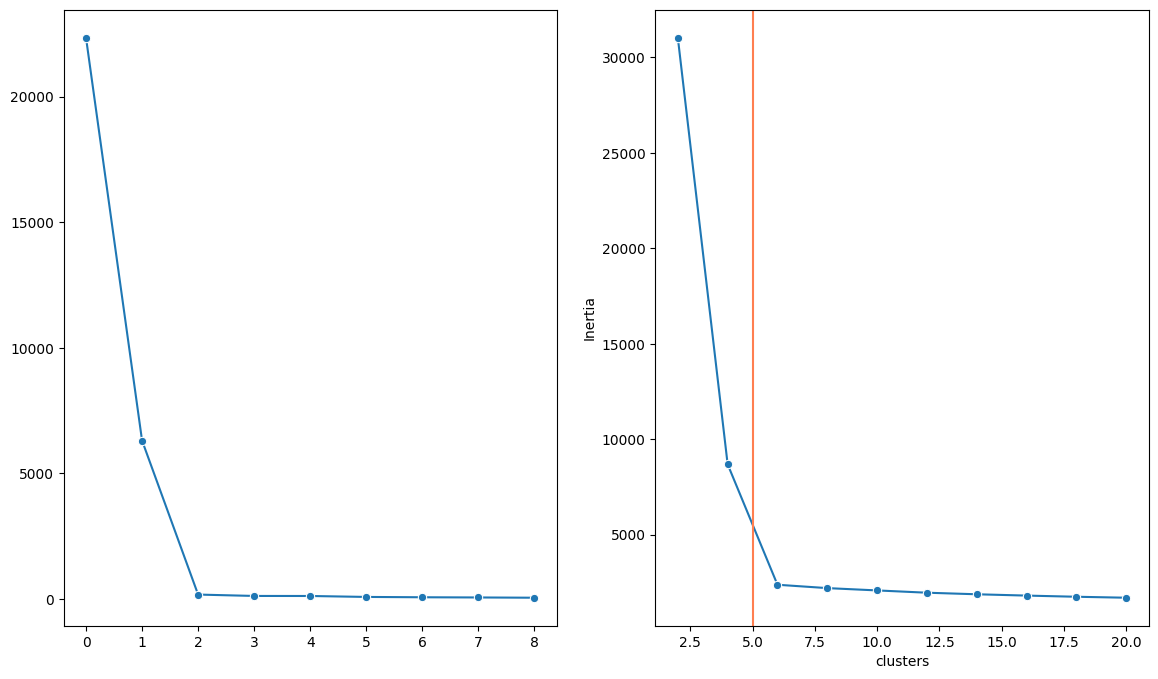

In [22]:
fig, axes = plt.subplots(1,2,figsize = (14,8))

sns.lineplot(
    data= n_clusters,
    x = 'clusters',
    y =  'Inertia',
    marker = 'o',
    ax= axes[1]
)

plt.axvline(5,color='coral')

sns.lineplot(
    data=  difference,
    marker = 'o',
    ax= axes[0]
)


## Evaluate silhouette score

In [12]:
# get the Silhouette score for the k-means model build for 3 clusters

kmeans_3c_silscore = silhouette_score(x_normalized,kmeans_3c.labels_)
kmeans_3c_silscore

0.5387622311830708

In [13]:
def silhouette_cluster_finding(x_vals,step:int = 1):
    
    sil_score = []
    n_clusters = []

    for i in range(2,21,step):
        kmeans_model = KMeans(n_clusters=i,random_state=42).fit(x_vals)
        model_sil_score = silhouette_score(x_vals,labels=kmeans_model.labels_)
        sil_score.append(model_sil_score)
        n_clusters.append(i)

    clusters_score = pd.DataFrame({
        'Clusters':n_clusters,
        'Silhouette_Score': sil_score
    })

    return clusters_score


In [15]:
cluster_eva = silhouette_cluster_finding(x_normalized,3)

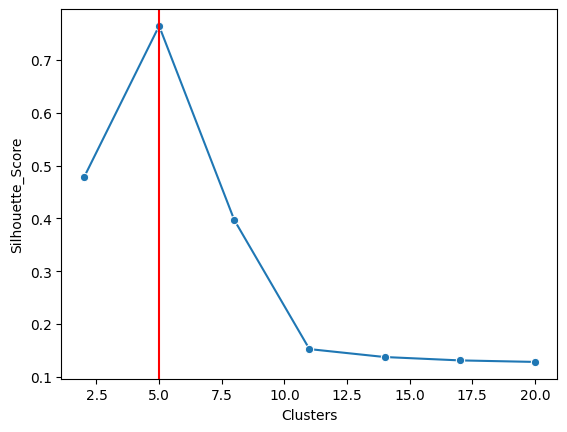

In [18]:
sns.lineplot(
    data=cluster_eva,
    x = 'Clusters',
    y = 'Silhouette_Score',
    marker= 'o'
)

plt.axvline(5,color='red')